# Lista 6

In [2]:
from torch.utils.data import DataLoader, random_split
import torch
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from torch import nn
from torchvision.transforms import functional as F


## Zadnie 0

In [3]:
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

target_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor()
])

dataset_trainval = datasets.OxfordIIITPet(
    root='./data',
    split='trainval',
    target_types='segmentation',
    download=True,
    transform=transform,
    target_transform=target_transform
)

dataset_test = datasets.OxfordIIITPet(
    root='./data',
    split='test',
    target_types='segmentation',
    download=True,
    transform=transform,
    target_transform=target_transform
)

train_size = int(0.8 * len(dataset_trainval))
val_size = len(dataset_trainval) - train_size
dataset_train, dataset_val = random_split(dataset_trainval, [train_size, val_size])


# DataLoadery
batch_size = 32

train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(dataset_val, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(dataset_test, batch_size=batch_size, shuffle=False, num_workers=0)

sample_img, sample_mask = dataset_trainval[0]

100%|██████████| 792M/792M [00:37<00:00, 21.2MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 9.96MB/s]


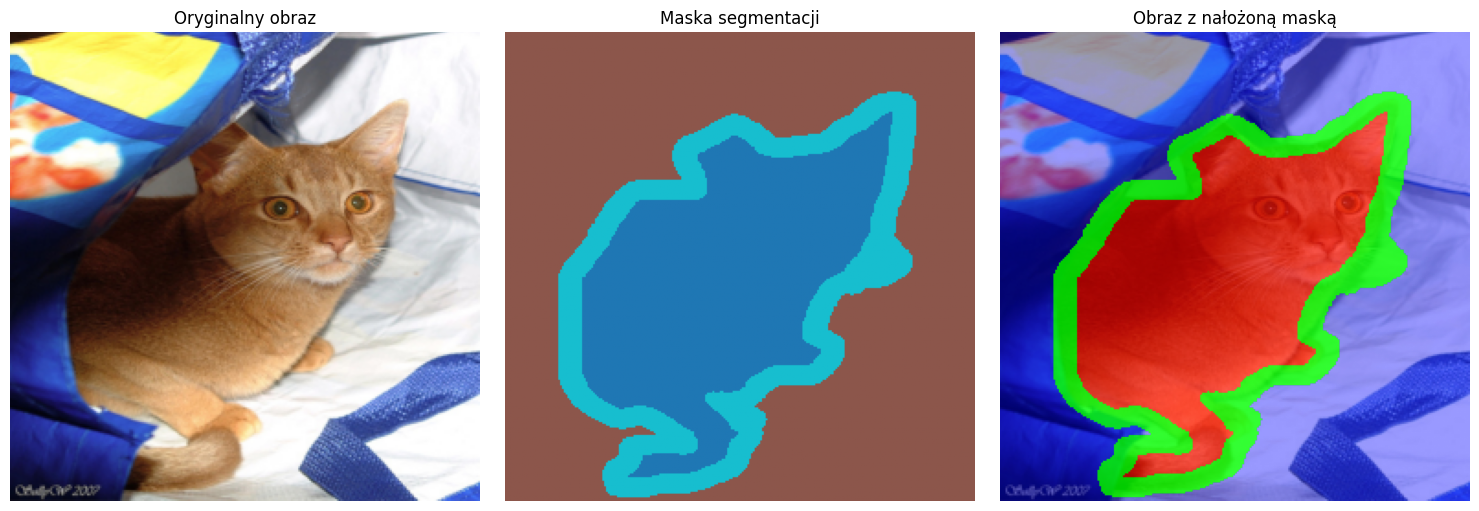

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Oryginalny obraz
img_display = sample_img.permute(1, 2, 0).numpy()
axes[0].imshow(img_display)
axes[0].set_title('Oryginalny obraz')
axes[0].axis('off')

# Maska segmentacji
mask_display = sample_mask.squeeze().numpy()
axes[1].imshow(mask_display, cmap='tab10')
axes[1].set_title('Maska segmentacji')
axes[1].axis('off')

# Obraz z nałożoną maską
axes[2].imshow(img_display)
mask_colored = np.zeros((*mask_display.shape, 4))
mask_colored[mask_display == 1] = [1, 0, 0, 0.6]
mask_colored[mask_display == 2] = [0, 0, 1, 0.4]
mask_colored[mask_display == 3] = [0, 1, 0, 0.8]
axes[2].imshow(mask_colored)
axes[2].set_title('Obraz z nałożoną maską')
axes[2].axis('off')

plt.tight_layout()
plt.show()


## Zad 1.1
pierwsza część U-net, zmniejszamy poolingiem wymiarowość, zwracając też przy okazji wartości do skip connection

In [5]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, hidden_channels: int = None):
        super().__init__()

        if not hidden_channels:
            hidden_channels = out_channels

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(hidden_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x_skip = self.conv(x)
        x_down = self.pool(x_skip)
        return x_skip, x_down

## Zadanie 1.2
Druga część, zwiększająca wymiar

In [6]:
class UpBlock(nn.Module):  # blok budulcowy dekodera
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # Dekonwolucja - zwiększa wymiary przestrzenne 2x i zmniejsza kanały
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        # Po konkatenacji mamy 2*out_channels (out_channels z up + out_channels ze skip)
        self.conv = DoubleConv(2 * out_channels, out_channels)

    def forward(self, x, s):
        # x - tensor z niższej warstwy dekodera
        # s - skip connection z enkodera (x_skip)
        x_up = self.up(x)
        x_cat = torch.cat([x_up, s], dim=1)
        y = self.conv(x_cat)
        return y


Test wymiarów

In [7]:
x = torch.randn(1, 3, 128, 128)
down_block = DownBlock(in_channels=3, out_channels=64)
up_block = UpBlock(in_channels=64, out_channels=64)

x_skip, x_down = down_block(x)
x_up = up_block(x_down, x_skip)

print(x_skip.shape, x_down.shape, x_up.shape)

torch.Size([1, 64, 128, 128]) torch.Size([1, 64, 64, 64]) torch.Size([1, 64, 128, 128])


z racji że nasz pooling zmniejsza o połowę to wymiary się zgadzają

## Zadanie 2.1
robimy podaną w notatniku strukturę, dane wejściowe muszą być wielokrotnością dwójki ponieważ przy maxpool wymiary zmniejszamy dwukrotnie więc przy 4 poziomach będziemy mieć wymiary 16 razy mniejsze (256/16 = 16 więc bottleneck to 16x16)

In [ ]:
class UNet(nn.Module):
    def __init__(self, in_channels: int = 3, num_classes: int = 3):
        super().__init__()

        # Enkoder - podwajamy liczbę kanałów: 64 → 128 → 256 → 512
        self.enc1 = DownBlock(in_channels, 64)
        self.enc2 = DownBlock(64, 128)
        self.enc3 = DownBlock(128, 256)
        self.enc4 = DownBlock(256, 512)

        # Bottleneck - najgłębsza warstwa
        self.bottleneck = DoubleConv(512, 1024)

        # Dekoder - dzielimy liczbę kanałów przez dwa: 512 → 256 → 128 → 64
        self.dec4 = UpBlock(1024, 512)
        self.dec3 = UpBlock(512, 256)
        self.dec2 = UpBlock(256, 128)
        self.dec1 = UpBlock(128, 64)

        # Warstwa wyjściowa - konwolucja 1x1 do redukcji kanałów do liczby klas
        self.output = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # Enkoder - zapisujemy skip connections
        s1, x1 = self.enc1(x)    # s1: (B, 64, H, W),      x1: (B, 64, H/2, W/2)
        s2, x2 = self.enc2(x1)   # s2: (B, 128, H/2, W/2), x2: (B, 128, H/4, W/4)
        s3, x3 = self.enc3(x2)   # s3: (B, 256, H/4, W/4), x3: (B, 256, H/8, W/8)
        s4, x4 = self.enc4(x3)   # s4: (B, 512, H/8, W/8), x4: (B, 512, H/16, W/16)

        # Bottleneck
        b = self.bottleneck(x4)  # b: (B, 1024, H/16, W/16)

        # Dekoder - używamy skip connections w odwrotnej kolejności
        d4 = self.dec4(b, s4)    # d4: (B, 512, H/8, W/8)
        d3 = self.dec3(d4, s3)   # d3: (B, 256, H/4, W/4)
        d2 = self.dec2(d3, s2)   # d2: (B, 128, H/2, W/2)
        d1 = self.dec1(d2, s1)   # d1: (B, 64, H, W)

        # Wyjście
        output = self.output(d1) # output: (B, num_classes, H, W)

        return output

## Zadanie 2.2
trenujemy Uneta

Using device: cuda
Epoch [1/12]
  Train Loss: 0.8386 | Val Loss: 0.9627
  Train Acc: Class0=0.445, Class1=0.807, Class2=0.080
  Val Acc:   Class0=0.955, Class1=0.511, Class2=0.032

Epoch [2/12]
  Train Loss: 0.6441 | Val Loss: 0.8442
  Train Acc: Class0=0.696, Class1=0.877, Class2=0.146
  Val Acc:   Class0=0.773, Class1=0.763, Class2=0.171

Epoch [3/12]
  Train Loss: 0.5883 | Val Loss: 0.5657
  Train Acc: Class0=0.733, Class1=0.893, Class2=0.192
  Val Acc:   Class0=0.732, Class1=0.910, Class2=0.224

Epoch [4/12]
  Train Loss: 0.5529 | Val Loss: 0.5686
  Train Acc: Class0=0.763, Class1=0.898, Class2=0.227
  Val Acc:   Class0=0.680, Class1=0.926, Class2=0.278

Epoch [5/12]
  Train Loss: 0.5225 | Val Loss: 0.6494
  Train Acc: Class0=0.786, Class1=0.901, Class2=0.266
  Val Acc:   Class0=0.915, Class1=0.782, Class2=0.215

Epoch [6/12]
  Train Loss: 0.4912 | Val Loss: 0.5231
  Train Acc: Class0=0.805, Class1=0.907, Class2=0.302
  Val Acc:   Class0=0.725, Class1=0.869, Class2=0.530

Epoch [7/

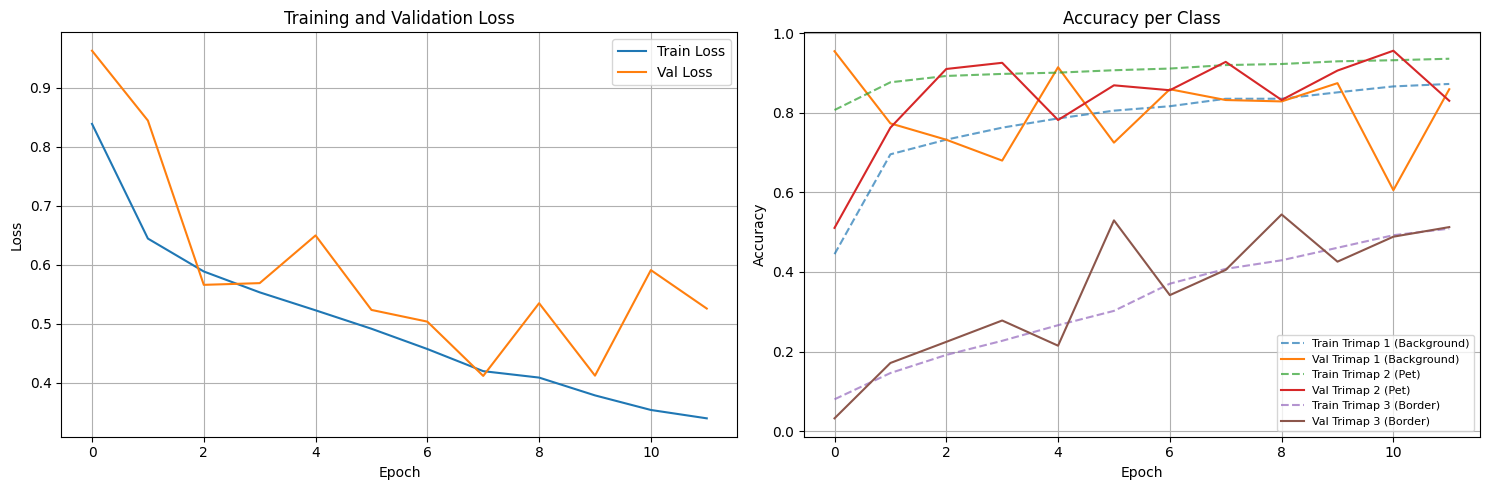

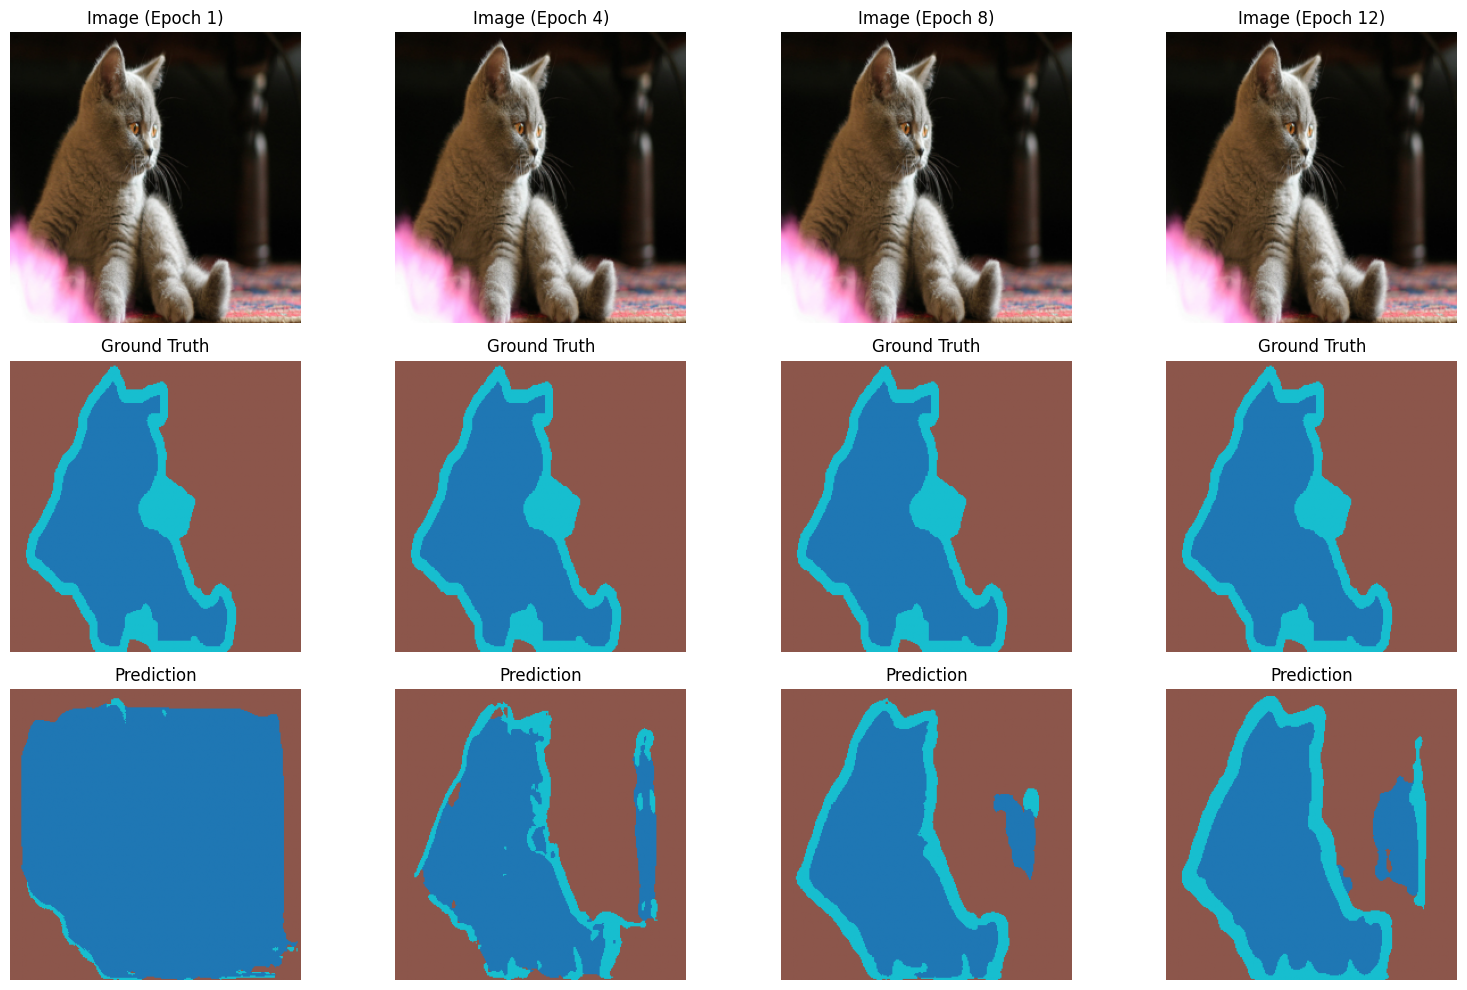

Model saved to unet_segmentation.pth


In [ ]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_per_class = torch.zeros(3)
    total_per_class = torch.zeros(3)

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device).squeeze(1).long()  # (B, 1, H, W) -> (B, H, W)
        masks = masks - 1  

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)  # (B, num_classes, H, W)
        loss = criterion(outputs, masks)

        # Backward pass
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)  # (B, H, W)
        for class_idx in range(3):
            mask_class = (masks == class_idx)
            if mask_class.sum() > 0:
                correct_per_class[class_idx] += ((preds == class_idx) & mask_class).sum().item()
                total_per_class[class_idx] += mask_class.sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    accuracy_per_class = correct_per_class / (total_per_class + 1e-8)

    return epoch_loss, accuracy_per_class


def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_per_class = torch.zeros(3)
    total_per_class = torch.zeros(3)

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device).squeeze(1).long()
            masks = masks - 1  

            outputs = model(images)
            loss = criterion(outputs, masks)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            for class_idx in range(3):
                mask_class = (masks == class_idx)
                if mask_class.sum() > 0:
                    correct_per_class[class_idx] += ((preds == class_idx) & mask_class).sum().item()
                    total_per_class[class_idx] += mask_class.sum().item()

    epoch_loss = running_loss / len(val_loader.dataset)
    accuracy_per_class = correct_per_class / (total_per_class + 1e-8)

    return epoch_loss, accuracy_per_class


def save_predictions(model, val_loader, device, epoch, predictions_history):
    model.eval()

    with torch.no_grad():
        images, masks = next(iter(val_loader))
        images = images.to(device)
        masks = masks.to(device).squeeze(1).long()
        masks = masks - 1 

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        predictions_history.append({
            'epoch': epoch,
            'image': images[0].cpu(),
            'mask_true': masks[0].cpu(),
            'mask_pred': preds[0].cpu()
        })


def train_model(model, train_loader, val_loader, num_epochs=50, lr=0.001, device='cuda', save_every=5):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Historie
    train_losses = []
    val_losses = []
    train_acc_history = {0: [], 1: [], 2: []}
    val_acc_history = {0: [], 1: [], 2: []}
    predictions_history = []

    for epoch in range(num_epochs):
        # Trening
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        train_losses.append(train_loss)
        for i in range(3):
            train_acc_history[i].append(train_acc[i].item())

        # Walidacja
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        for i in range(3):
            val_acc_history[i].append(val_acc[i].item())

        # Zapisz predykcje co save_every epok
        if (epoch + 1) % save_every == 0 or epoch == 0:
            save_predictions(model, val_loader, device, epoch + 1, predictions_history)

        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"  Train Acc: Class0={train_acc[0]:.3f}, Class1={train_acc[1]:.3f}, Class2={train_acc[2]:.3f}")
        print(f"  Val Acc:   Class0={val_acc[0]:.3f}, Class1={val_acc[1]:.3f}, Class2={val_acc[2]:.3f}")
        print()

    # Wyświetl krzywe uczenia
    plot_training_curves(train_losses, val_losses, train_acc_history, val_acc_history)

    # Wyświetl ewolucję predykcji
    plot_prediction_evolution(predictions_history)

    return model, predictions_history


def plot_training_curves(train_losses, val_losses, train_acc_history, val_acc_history):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Loss
    axes[0].plot(train_losses, label='Train Loss')
    axes[0].plot(val_losses, label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Accuracy per class
    class_names = ['Trimap 1 (Background)', 'Trimap 2 (Pet)', 'Trimap 3 (Border)']
    for class_idx in range(3):
        axes[1].plot(train_acc_history[class_idx], label=f'Train {class_names[class_idx]}', linestyle='--', alpha=0.7)
        axes[1].plot(val_acc_history[class_idx], label=f'Val {class_names[class_idx]}')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy per Class')
    axes[1].legend(fontsize=8)
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


def plot_prediction_evolution(predictions_history):
    """Wizualizacja ewolucji predykcji podczas treningu"""
    n_snapshots = len(predictions_history)
    fig, axes = plt.subplots(3, n_snapshots, figsize=(4*n_snapshots, 10))

    if n_snapshots == 1:
        axes = axes.reshape(-1, 1)

    for idx, pred_dict in enumerate(predictions_history):
        epoch = pred_dict['epoch']
        image = pred_dict['image'].permute(1, 2, 0).numpy()
        mask_true = pred_dict['mask_true'].numpy()
        mask_pred = pred_dict['mask_pred'].numpy()

        # Oryginalny obraz
        axes[0, idx].imshow(image)
        axes[0, idx].set_title(f'Image (Epoch {epoch})')
        axes[0, idx].axis('off')

        # Prawdziwa maska
        axes[1, idx].imshow(mask_true, cmap='tab10', vmin=0, vmax=2)
        axes[1, idx].set_title('Ground Truth')
        axes[1, idx].axis('off')

        # Predykcja
        axes[2, idx].imshow(mask_pred, cmap='tab10', vmin=0, vmax=2)
        axes[2, idx].set_title(f'Prediction')
        axes[2, idx].axis('off')

    plt.tight_layout()
    plt.show()


# Przykład użycia:
if __name__ == "__main__":
    # Wybierz urządzenie
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Utwórz model
    model = UNet(in_channels=3, num_classes=3)

    # Trenuj model
    trained_model, predictions = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=12,
        lr=0.001,
        device=device,
        save_every=4
    )

Widać że model się czegoś nauczył. Wiadomo, możnaby dostroić hiperparametry, zwiększyć liczbę epok itd żeby wynik był jeszcze lepszy ale jak na takie bare minimum zastosowane to i tak nie ma co narzekać. Ewidentnie najlepiej model uczy się zwierzęcia, następnie nieco gorzej ale dalej przyzwoicie tła a najgorzej idzie mu z obramowaniem co jest logiczne

## Zadanie 3.1
teraz zrobimy autoenkoder

In [9]:
class Encoder(nn.Module): # oddzielne sieci dla przejrzystości i łatwości dalszego użycia
    def __init__(self, in_channels: int = 3, bottleneck_channels: int = 1024):
        super().__init__()
        # Enkoder - zmniejszamy wymiary przestrzenne, zwiększamy liczbę kanałów
        self.enc1 = nn.Sequential(
            DoubleConv(in_channels, 64),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.enc2 = nn.Sequential(
            DoubleConv(64, 128),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.enc3 = nn.Sequential(
            DoubleConv(128, 256),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.enc4 = nn.Sequential(
            DoubleConv(256, 512),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Bottleneck
        self.bottleneck = DoubleConv(512, bottleneck_channels)
        self.bottleneck_channels = bottleneck_channels

    def forward(self, x):
        x1 = self.enc1(x)    # (B, 64, H/2, W/2)
        x2 = self.enc2(x1)   # (B, 128, H/4, W/4)
        x3 = self.enc3(x2)   # (B, 256, H/8, W/8)
        x4 = self.enc4(x3)   # (B, 512, H/16, W/16)
        b = self.bottleneck(x4)  # (B, 1024, H/16, W/16)
        return b


class Decoder(nn.Module):
    def __init__(self, out_channels: int = 3, bottleneck_channels: int = 1024):
        super().__init__()
        # Dekoder - zwiększamy wymiary przestrzenne, zmniejszamy liczbę kanałów
        self.dec4 = nn.Sequential(
            nn.ConvTranspose2d(bottleneck_channels, 512, kernel_size=2, stride=2),
            DoubleConv(512, 512)
        )
        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2),
            DoubleConv(256, 256)
        )
        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            DoubleConv(128, 128)
        )
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            DoubleConv(64, 64)
        )

        # Warstwa wyjściowa
        self.output = nn.Conv2d(64, out_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        d4 = self.dec4(x)    # (B, 512, H/8, W/8)
        d3 = self.dec3(d4)   # (B, 256, H/4, W/4)
        d2 = self.dec2(d3)   # (B, 128, H/2, W/2)
        d1 = self.dec1(d2)   # (B, 64, H, W)
        output = self.output(d1)  # (B, 3, H, W)
        output = self.sigmoid(output)
        return output


class CNNAutoencoder(nn.Module): # łączymy tutaj logikę enkodera i dekodera
    def __init__(self, in_channels: int = 3, out_channels: int = 3, bottleneck_channels: int = 1024):
        super().__init__()
        self.encoder = Encoder(in_channels, bottleneck_channels)
        self.decoder = Decoder(out_channels, bottleneck_channels)
        self.bottleneck_channels = bottleneck_channels

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

    def embeddings(self, x): # użyj tylko enkodera i zwróc spłaszczony wynik
        encoded = self.encoder(x)
        # Spłaszczamy do wektora
        return encoded.view(encoded.size(0), -1)

## Zadnie 3.2
Najpierw wprowadzę funkcje użyte do treningu

In [10]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, _ in dataloader:
        images = images.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, images)

        # Backward pass
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss


def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)

            outputs = model(images)
            loss = criterion(outputs, images)

            running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss


def get_reconstructions(model, dataloader, device, num_samples=8):
    model.eval()
    images_list = []
    reconstructions_list = []

    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            outputs = model(images)

            images_list.append(images.cpu())
            reconstructions_list.append(outputs.cpu())

            if len(images_list) * images.size(0) >= num_samples:
                break

    images_tensor = torch.cat(images_list, dim=0)[:num_samples]
    reconstructions_tensor = torch.cat(reconstructions_list, dim=0)[:num_samples]

    return images_tensor, reconstructions_tensor


def visualize_reconstructions(original, reconstructed, epoch, bottleneck_size):

    num_images = min(8, original.size(0))
    fig, axes = plt.subplots(2, num_images, figsize=(20, 5))

    for i in range(num_images):
        # Oryginalny obraz
        axes[0, i].imshow(original[i].permute(1, 2, 0).numpy())
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Oryginał', fontsize=12)

        # Zrekonstruowany obraz
        axes[1, i].imshow(reconstructed[i].permute(1, 2, 0).numpy())
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Rekonstrukcja', fontsize=12)

    plt.suptitle(f'Bottleneck={bottleneck_size}, Epoka {epoch}', fontsize=14)
    plt.tight_layout()
    plt.close()


def plot_training_history(train_losses, val_losses, bottleneck_size):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss', linewidth=2)
    plt.plot(val_losses, label='Validation Loss', linewidth=2)
    plt.xlabel('Epoka', fontsize=12)
    plt.ylabel('Loss (MSE)', fontsize=12)
    plt.title(f'Historia treningu - Bottleneck={bottleneck_size}', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.close()


def train_autoencoder(bottleneck_size, num_epochs=20, learning_rate=0.001, save_reconstructions_every=5):

    print(f"")
    print(f"Trenuję autoencoder z bottleneck_size={bottleneck_size}")
    print(f"")

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = CNNAutoencoder(in_channels=3, out_channels=3, bottleneck_channels=bottleneck_size)
    model = model.to(device)

    # Loss i optimizer
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Historie
    train_losses = []
    val_losses = []

    # Trening
    for epoch in range(1, num_epochs + 1):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = validate_epoch(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoka {epoch}/{num_epochs} - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

        # Zapisz rekonstrukcje co kilka epok
        if epoch % save_reconstructions_every == 0 or epoch == 1 or epoch == num_epochs:
            original, reconstructed = get_reconstructions(model, val_loader, device)
            visualize_reconstructions(original, reconstructed, epoch, bottleneck_size)


    # Wykres historii treningu
    plot_training_history(train_losses, val_losses, bottleneck_size)

    return model, train_losses, val_losses

Trenowanie


Trenuję autoencoder z bottleneck_size=4

Epoka 1/9 - Train Loss: 0.022537, Val Loss: 0.014466
Epoka 2/9 - Train Loss: 0.013599, Val Loss: 0.012502
Epoka 3/9 - Train Loss: 0.012369, Val Loss: 0.011921
Epoka 4/9 - Train Loss: 0.011716, Val Loss: 0.012729
Epoka 5/9 - Train Loss: 0.011170, Val Loss: 0.010177
Epoka 6/9 - Train Loss: 0.011173, Val Loss: 0.010691
Epoka 7/9 - Train Loss: 0.010571, Val Loss: 0.012653
Epoka 8/9 - Train Loss: 0.009695, Val Loss: 0.023089
Epoka 9/9 - Train Loss: 0.008471, Val Loss: 0.017159

Trenuję autoencoder z bottleneck_size=16

Epoka 1/9 - Train Loss: 0.021952, Val Loss: 0.016510
Epoka 2/9 - Train Loss: 0.013005, Val Loss: 0.012061
Epoka 3/9 - Train Loss: 0.011590, Val Loss: 0.011943
Epoka 4/9 - Train Loss: 0.010817, Val Loss: 0.009742
Epoka 5/9 - Train Loss: 0.010233, Val Loss: 0.009600
Epoka 6/9 - Train Loss: 0.010092, Val Loss: 0.009811
Epoka 7/9 - Train Loss: 0.009185, Val Loss: 0.012038
Epoka 8/9 - Train Loss: 0.007958, Val Loss: 0.007884
Epoka 9/9 - Tr

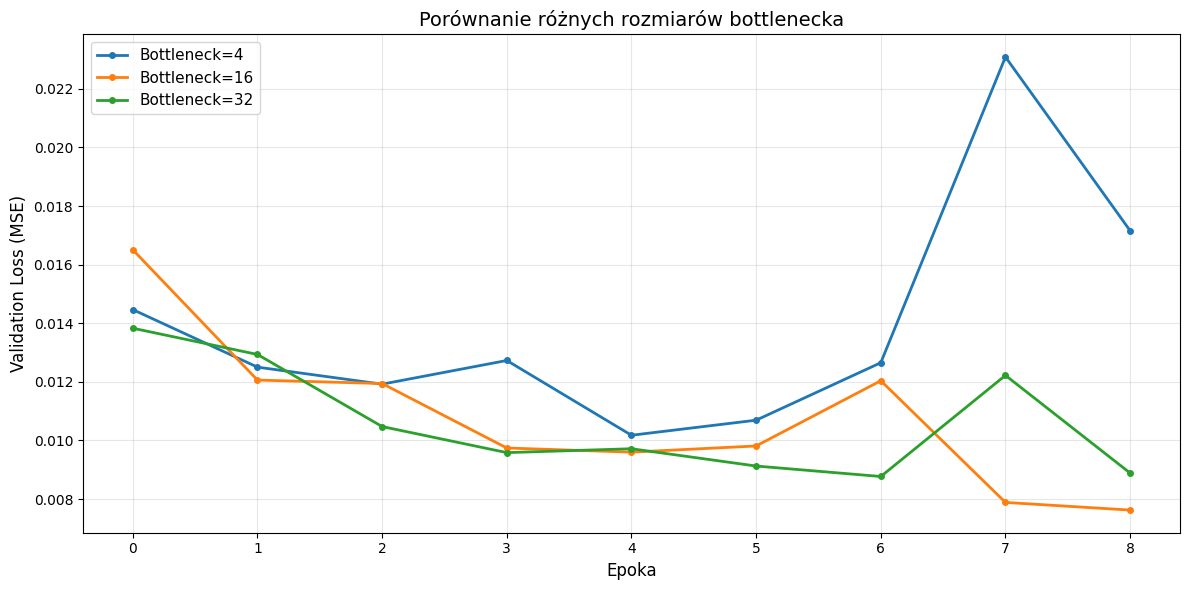

In [11]:
bottleneck_sizes = [4, 16, 32]

results = {}

for bottleneck_size in bottleneck_sizes:
    model, train_losses, val_losses = train_autoencoder(
        bottleneck_size=bottleneck_size,
        num_epochs=9,
        learning_rate=0.001,
        save_reconstructions_every=3
    )
    results[bottleneck_size] = {
        'model': model,
        'train_losses': train_losses,
        'val_losses': val_losses
    }

# Porównanie wszystkich eksperymentów
print("")
print("PODSUMOWANIE EKSPERYMENTÓW")
print("")

plt.figure(figsize=(12, 6))

for bottleneck_size in bottleneck_sizes:
    val_losses = results[bottleneck_size]['val_losses']
    plt.plot(val_losses, label=f'Bottleneck={bottleneck_size}', linewidth=2, marker='o', markersize=4)
    final_loss = val_losses[-1]
    print(f"Bottleneck={bottleneck_size:3d} - Końcowy Val Loss: {final_loss:.6f}")

plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Validation Loss (MSE)', fontsize=12)
plt.title('Porównanie różnych rozmiarów bottlenecka', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

Zgodnie z intuicją, mały bottleneck zapamiętuje wyłącznie główne wzorce, stąd loss jest większy od reszty. Im większy bottleneck, tym dokładniejsze detale możemy w nim uchwycić, ale zbyt duże bottlenecki doprowadzają do overfittingu, więc trzeba tutaj zachować balans między biasem a wariancją.
Wartości loss są małe  bo używamy MSE, który nakłada pierwiastek więc 0.01 to loss na poziomie 10% no i tutaj ponownie, gdyby dostroić hiperparametry itp to zrobimy lepszy wynik ale to już było.